                  profit_and_loss    spread  volume_imbalance  mid_price
profit_and_loss          1.000000  0.529064         -0.027252   0.677220
spread                   0.529064  1.000000          0.000961   0.758817
volume_imbalance        -0.027252  0.000961          1.000000  -0.009772
mid_price                0.677220  0.758817         -0.009772   1.000000


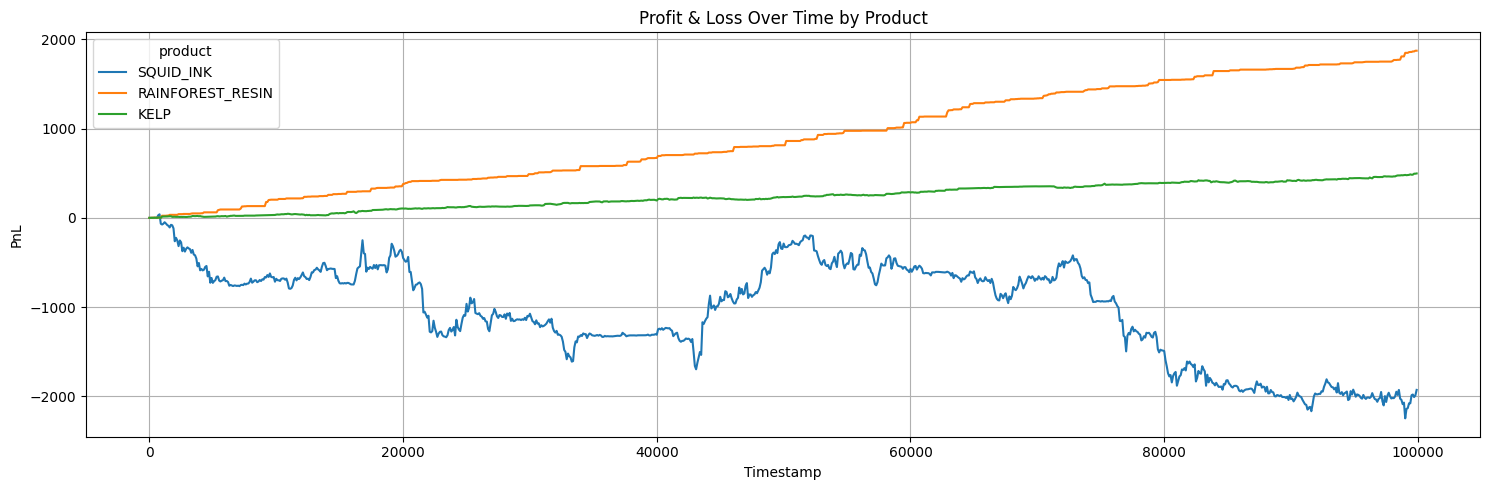

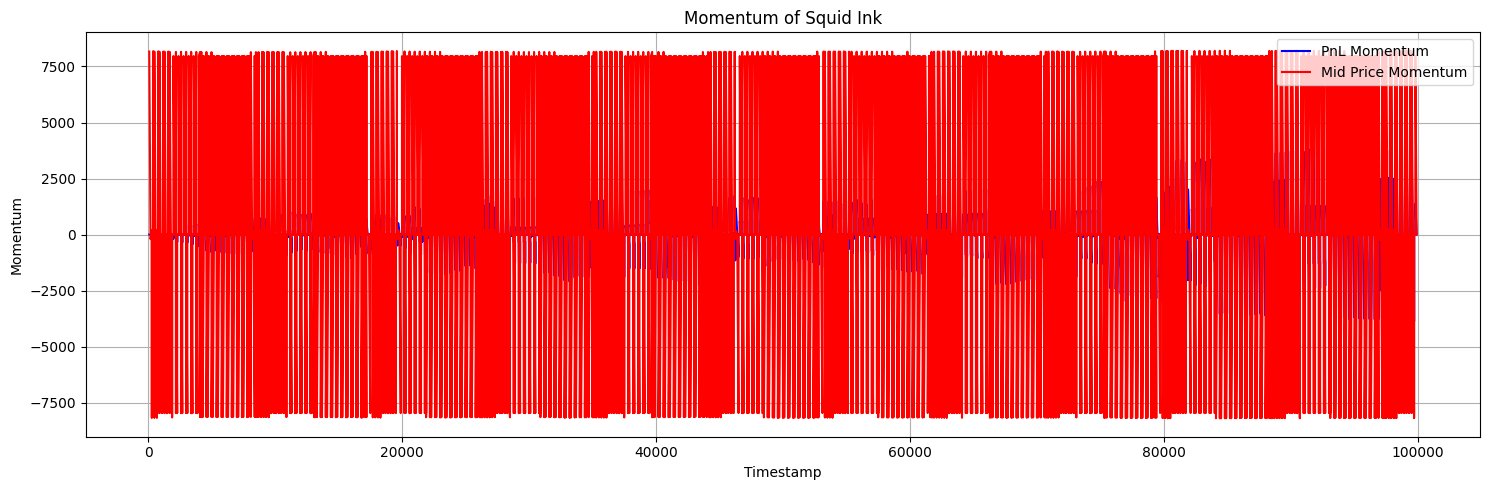

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\AHILI\OneDrive\Desktop\imcpattern.csv", delimiter = ";")

df["pnl_diff"] = df.groupby("product")["profit_and_loss"].diff().fillna(0)


#correlation
df["spread"] = df["ask_price_1"] - df["bid_price_1"]
df["volume_imbalance"] = (df["bid_volume_1"] - df["ask_volume_1"]) / \
                         (df["bid_volume_1"] + df["ask_volume_1"] + 1e-5)  
print(df[["profit_and_loss", "spread","volume_imbalance", "mid_price"]].corr())

#plotting pnl
plt.figure(figsize=(15, 5))
sns.lineplot(data=df, x="timestamp", y="profit_and_loss", hue="product")
plt.title("Profit & Loss Over Time by Product")
plt.xlabel("Timestamp")
plt.ylabel("PnL")
plt.grid(True)
plt.tight_layout()
plt.show()

#momentum
df["pnl_momentum"]= df["profit_and_loss"].diff(periods = 5)
df["mid_price_momentum"] = df["mid_price"].diff(periods = 5)

#plotting momentum
plt.figure(figsize=(15, 5))
plt.plot(df["timestamp"], df["pnl_momentum"], label="PnL Momentum", color="blue")
plt.plot(df["timestamp"], df["mid_price_momentum"], label="Mid Price Momentum", color="red")
plt.title("Momentum of Squid Ink")
plt.xlabel("Timestamp")
plt.ylabel("Momentum")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


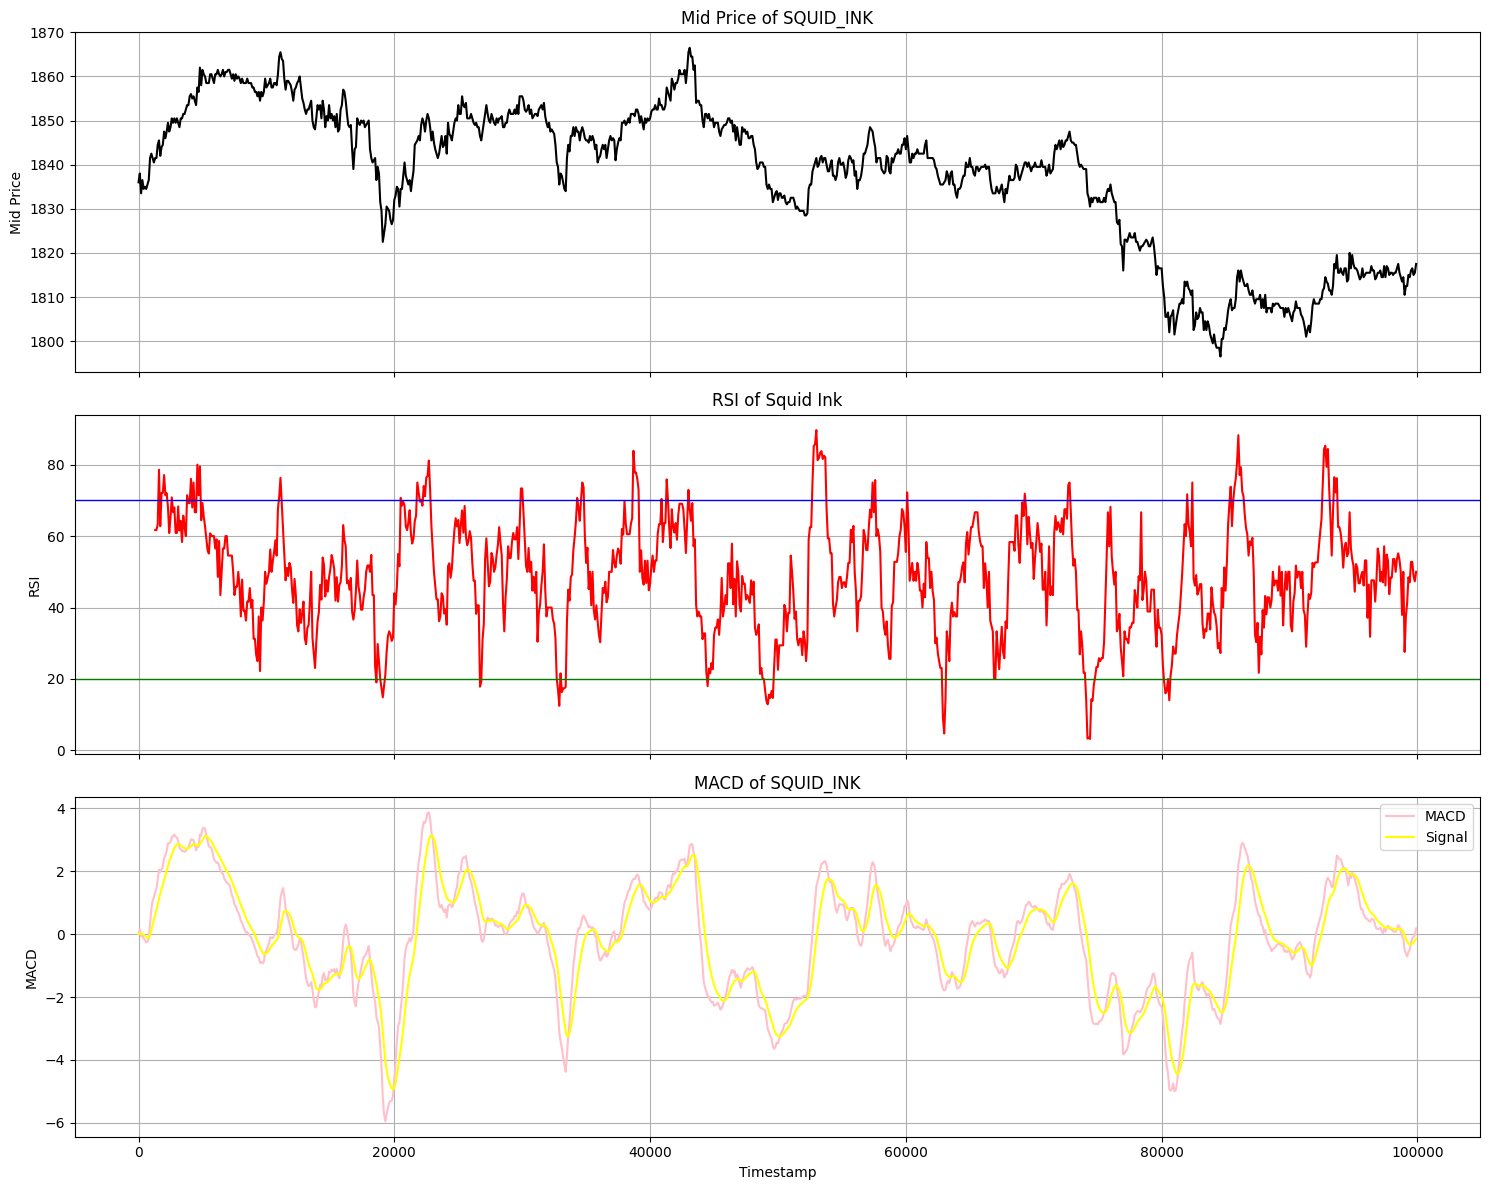

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\AHILI\OneDrive\Desktop\imcpattern.csv", delimiter = ";")
squid_df = df[df["product"] == "SQUID_INK"].copy()
squid_df["returns"] = squid_df["mid_price"].pct_change()

#rsi
window_length =  14
delta = squid_df["mid_price"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window = window_length).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window = window_length).mean()
rsi = gain / loss
squid_df["RSI"] = 100 - (100 / (1 + rsi))

#macd
exp1 = squid_df["mid_price"].ewm(span = 12, adjust = False).mean()
exp2 = squid_df["mid_price"].ewm(span = 26, adjust = False).mean()
squid_df["MacD"] = exp1 - exp2
squid_df["Signal"] = squid_df["MacD"].ewm(span = 10, adjust = False).mean()
#plotting rsi and macd
fig, axes = plt.subplots(3, 1, figsize = (15, 12), sharex = True)

#midprice
axes[0].plot(squid_df["timestamp"], squid_df["mid_price"], label="Mid Price", color="black")
axes[0].set_title("Mid Price of SQUID_INK")
axes[0].set_ylabel("Mid Price")
axes[0].grid(True)

#rsi
axes[1].plot(squid_df["timestamp"], squid_df["RSI"], label = "RSI", color = "red")
axes[1].axhline(70, color = 'blue', linestyle = 'solid', linewidth = 1)
axes[1].axhline(20, color = 'green', linestyle = 'solid', linewidth = 1)
axes[1].set_title("RSI of Squid Ink")
axes[1].set_ylabel("RSI")
axes[1].grid(True)

#macd
axes[2].plot(squid_df["timestamp"], squid_df["MacD"], label = "MACD", color = "pink")
axes[2].plot(squid_df["timestamp"], squid_df["Signal"], label = "Signal", color = "yellow")
axes[2].set_title("MACD of SQUID_INK")
axes[2].set_ylabel("MACD")
axes[2].grid(True)
axes[2].legend()

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()